# Exercise 3: Hazard classification from exceedance probabilities

Four rasters, each giving the probability that flooding reaches a particular depth.
This notebook combines them into a single hazard classification and then works out which buildings and roads fall inside each level.

The question being answered is different from Exercise 2:

> **What are the odds of at least 30 cm of water here?**

Exercise 2 sampled *depth* from one specific storm. This works from
**exceedance probabilities** across an ensemble, which is a more useful product for
a forecast.

**What to take away from it**

- how four nested probability layers collapse into one classification, and why the
  rule assigns levels in ascending order
- why a threshold is a modelling decision rather than a detail, and why you should
  check what range the data can actually reach before exposing one
- how to recover an undocumented sampling method from the data itself, and when to
  stop and report the residual rather than claim a match
- why zonal statistics are a property of the grid as much as of the geometry

**Workflow**

1. Classify pixels into hazard levels with the escalating-gate rule
2. Discover a constraint in the data that limits what the top level can mean
3. Classify the buildings and roads directly, and verify how they were sampled
4. Build the impact table

Everything is read from a public S3 bucket. Nothing is stored locally.

In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
from matplotlib.colors import BoundaryNorm, ListedColormap

%matplotlib inline

BUCKET = "https://cog-s3-test-401506828094-us-east-1-an.s3.us-east-1.amazonaws.com"
PROB = {                                    # EPSG:3857 copies, all on one grid
    "7p62": f"{BUCKET}/PBI_Actividad_2/prob_7p62.tif",
    "10cm": f"{BUCKET}/PBI_Actividad_2/prob_10cm.tif",
    "30cm": f"{BUCKET}/PBI_Actividad_2/prob_30cm.tif",
    "76cm": f"{BUCKET}/PBI_Actividad_2/prob_76cm.tif",
}
FEATURES = f"{BUCKET}/Guatemala_IBF/impact_features.csv"

print("ready")

ready


## 1. The four probability rasters

Each raster holds **P(flood depth ≥ threshold)** for one depth, produced from an
EF5 ensemble. A cell value of 0.3 in the 30 cm raster means *"in 30% of the
ensemble members, the water here reached at least 30 cm"*.

In [2]:
layers, meta = {}, {}
for name, url in PROB.items():
    with rasterio.open(url) as ds:
        layers[name] = ds.read(1, masked=True)
        meta[name] = {"crs": ds.crs, "shape": ds.shape,
                      "transform": ds.transform, "res": ds.res[0]}

for name, m in meta.items():
    print(f"prob_{name:<5} {m['crs']}  {m['shape']}  {m['res']:.0f} m")

shapes_seen = {v.shape for v in layers.values()}
print(f"\nall four share one grid: {len(shapes_seen) == 1}")

prob_7p62  EPSG:3857  (424, 319)  5 m
prob_10cm  EPSG:3857  (424, 319)  5 m
prob_30cm  EPSG:3857  (424, 319)  5 m
prob_76cm  EPSG:3857  (424, 319)  5 m

all four share one grid: True


## 2. The classification rule (Review from UFFIS notebook)

Each hazard level is tied to **one** depth layer, and each has its own probability
gate:

| level | driven by | notebook default gate |
|---|---|---|
| Bajo / Low | P(≥ 7.6 cm) | 0.8 |
| Medio / Medium | P(≥ 10 cm) | 0.8 |
| Alto / High | P(≥ 30 cm) | 0.8 |
| Severo / Severe | P(≥ 76 cm) | 0.2 |

A pixel takes the level of the **deepest** threshold whose gate it clears. That
falls out of assigning the levels in ascending order and letting later assignments
win.

This is a faithful port of `clasificar_peligro` from the UFFIS notebook.

> **Why the Severe gate is 0.2 and not 0.8.** The 76 cm raster only ever contains
> the values 0 and 0.2, so no pixel can clear a higher gate. At 0.8 the Severe
> class would be *unreachable* and the colour would simply never appear.

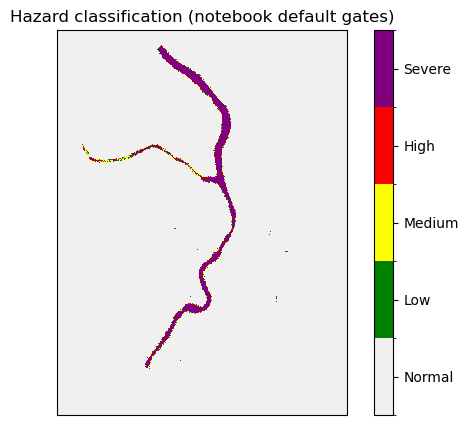

In [3]:
LEVELS = [(1, "green"), (2, "yellow"), (3, "red"), (4, "purple")]
LEVEL_LABEL = {0: "Normal", 1: "Low", 2: "Medium", 3: "High", 4: "Severe"}
NODATA = 255
ORDER = ["7p62", "10cm", "30cm", "76cm"]      # shallowest to deepest
LOW_THRESHOLD = 0.8
MEDIUM_THRESHOLD = 0.8
HIGH_THRESHOLD = 0.8
SEVERE_THRESHOLD = 0.2


def clasificar_peligro(layers, gates):
    """0 = Normal, 1..4 = hazard level, 255 = NoData."""
    # A pixel missing from any layer cannot be classified at all.
    invalid = np.zeros(layers[ORDER[0]].shape, dtype=bool)
    for name in ORDER:
        invalid |= np.ma.getmaskarray(layers[name])

    hazard = np.zeros(layers[ORDER[0]].shape, dtype=np.uint8)
    # Ascending order: each assignment overwrites the last, so the deepest
    # threshold a pixel clears is the one that sticks.
    for name, (value, _colour) in zip(ORDER, LEVELS):
        hazard[layers[name].filled(-np.inf) >= gates[value]] = value

    hazard[invalid] = NODATA
    return hazard

GATES = {1: LOW_THRESHOLD, 2: MEDIUM_THRESHOLD, 3: HIGH_THRESHOLD, 4: SEVERE_THRESHOLD}
hazard = clasificar_peligro(layers, GATES)

cmap = ListedColormap(["#f0f0f0", "green", "yellow", "red", "purple"])
norm = BoundaryNorm([0, 1, 2, 3, 4, 5], cmap.N)

fig, ax = plt.subplots(figsize=(7, 5))
drawn = np.where(hazard == NODATA, np.nan, hazard)
im = ax.imshow(drawn, cmap=cmap, norm=norm, interpolation="nearest")
ax.set_title("Hazard classification (notebook default gates)")
ax.set_xticks([]); ax.set_yticks([])
cbar = fig.colorbar(im, ax=ax, ticks=[0.5, 1.5, 2.5, 3.5, 4.5])
cbar.ax.set_yticklabels([LEVEL_LABEL[v] for v in [0, 1, 2, 3, 4]])
plt.show()

## 3. Classifying the buildings and roads

Each building and road in the IBF data **already carries the
four probabilities** so we can pull from that directly.

In [4]:
features = pd.read_csv(FEATURES)
PROB_FIELDS = ["probability_7p62cm", "probability_10cm",
               "probability_30cm", "probability_76cm"]

print(f"{len(features):,} features")
print(features.tipo.value_counts().to_string())
print()
features[["tipo"] + PROB_FIELDS].head(3)

5,147 features
tipo
edificio     4689
carretera     458



,tipo,probability_7p62cm,probability_10cm,probability_30cm,probability_76cm
0,edificio,0.0,0.0,0.0,0.0
1,edificio,0.0,0.0,0.0,0.0
2,edificio,0.0,0.0,0.0,0.0


In [5]:
def classify_features(df, gates):
    hazard = pd.Series(0, index=df.index, dtype="uint8")
    for field, (value, _colour) in zip(PROB_FIELDS, LEVELS):
        hazard[df[field] >= gates[value]] = value      # deepest gate cleared wins
    return hazard


features["hazard"] = classify_features(features, GATES)
features["level"] = features.hazard.map(LEVEL_LABEL)
features.level.value_counts().to_frame("features")

,features
level,
Normal,4981
Severe,92
Low,43
Medium,23
High,8


## 4. The impact table

Deepest level first; Normal is left out because it is everything the gates did not
catch, so it carries no exposure.

In [6]:
TOTAL_POPULATION = 290_868          # every building in the geopackage


def impact_row(name, group):
    buildings = group[group.tipo == "edificio"]
    return {
        "Level": name,
        "Buildings": f"{len(buildings):,}",
        "Population": f"{group.poblacion.sum():,.0f}",
        "Area (m²)": f"{group.area_m2.sum():,.0f}",
        "Roads (km)": f"{group.longitud_m.sum() / 1000:,.1f}",
        "% of population": f"{100 * group.poblacion.sum() / TOTAL_POPULATION:.2f}%",
    }


at_risk = features[features.hazard > 0]
table = [impact_row(LEVEL_LABEL[v], at_risk[at_risk.hazard == v])
         for v, _c in reversed(LEVELS)]
table.append(impact_row("TOTAL at risk", at_risk))

pd.DataFrame(table).set_index("Level")

,Buildings,Population,Area (m²),Roads (km),% of population
Level,,,,,
Severe,80,160,"4,939",1.0,0.05%
High,8,14,447,0.0,0.00%
Medium,19,51,"1,600",0.6,0.02%
Low,28,82,"2,597",1.4,0.03%
TOTAL at risk,135,307,"9,583",2.9,0.11%


## 5. Mapping it

The classified grid with the affected buildings and roads on top.

Both have to be in the *same* CRS to overlay: the features are stored in
UTM 15N and the rasters here are the EPSG:3857 copies, so the features get
reprojected onto the raster's grid before anything is drawn.

/tmp/ipykernel_72069/4150271324.py:38: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(loc="lower left", fontsize=8)


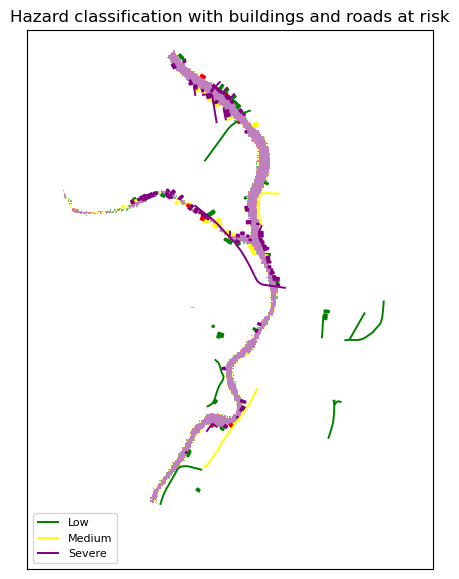

In [7]:
from rasterio.transform import array_bounds

NATIVE = f"{BUCKET}/Guatemala_IBF/guatemala_flood_30cm_probability_clipped.tif"
FIELD = "probability_30cm"

with rasterio.open(NATIVE) as ds:
    native_band = ds.read(1, masked=True).filled(0.0)
    native_shape, native_transform, native_crs = ds.shape, ds.transform, ds.crs
geo = gpd.read_file(f"{BUCKET}/Guatemala_IBF/impact_features.geojson").to_crs(native_crs)

grid_crs = meta["30cm"]["crs"]
rows, cols = meta["30cm"]["shape"]
left, bottom, right, top = array_bounds(rows, cols, meta["30cm"]["transform"])

# Same CRS or the two layers will not line up.
geo_grid = geo.to_crs(grid_crs)
geo_grid["hazard"] = classify_features(
    geo_grid.assign(**{f: geo_grid[f].fillna(0.0) for f in PROB_FIELDS}), GATES
)

fig, ax = plt.subplots(figsize=(8, 7))

# Normal and NoData left transparent so the classified areas read clearly.
shaded = np.where((hazard > 0) & (hazard != NODATA), hazard, np.nan).astype("float32")
ax.imshow(shaded, cmap=cmap, norm=norm, interpolation="nearest",
          extent=(left, right, bottom, top), alpha=0.5)

for value, colour in LEVELS:
    subset = geo_grid[geo_grid.hazard == value]
    if not subset.empty:
        subset.plot(ax=ax, color=colour, linewidth=1.4, edgecolor=colour,
                    label=LEVEL_LABEL[value])

ax.set_xlim(left, right)
ax.set_ylim(bottom, top)
ax.set_title("Hazard classification with buildings and roads at risk")
ax.set_xticks([]); ax.set_yticks([])
ax.legend(loc="lower left", fontsize=8)
plt.show()

## 6. How the dashboard plugins do it

Everything above runs here, in a notebook. To put it on a dashboard the same code
has to become a **plugin**: an installable Python package that TethysDash finds on
its own. The computation does not change — what follows is only the wrapper, and
the contracts that wrapper has to satisfy.

### Discovery — how the app finds it

A plugin is a class registered as an **Intake entry point** in its package's
`pyproject.toml`. Note that every plugin here ships twice, once per language:

```toml
[project.entry-points."intake.drivers"]
wmo_impact_summary_en = "tgf_wmo_plugins.impact_summary:ImpactSummaryEN"
wmo_impact_summary_es = "tgf_wmo_plugins.impact_summary:ImpactSummaryES"
wmo_hazard_layer_en   = "tgf_wmo_plugins.hazard_layer:HazardLayerEN"
wmo_hazard_layer_es   = "tgf_wmo_plugins.hazard_layer:HazardLayerES"
wmo_impact_layer_en   = "tgf_wmo_plugins.impact_layer:ImpactLayerEN"
wmo_impact_layer_es   = "tgf_wmo_plugins.impact_layer:ImpactLayerES"
```

Once the plugin is installed with TethysDash, users can integrate it into
their own dashboards to view the results.

### The class — discovery properties, args, and one method

```python
from tethysapp.tethysdash.plugin_helpers import TethysDashPlugin


class ImpactSummaryEN(TethysDashPlugin):

    # ---- discovery: how the GUI lists and presents this plugin -----------
    name = "wmo_impact_summary_en"           # must match the entry-point key
    label = "Flood Impact Summary (English)" # the row in the dropdown
    group = "Flood Maps (English)"           # the heading it is filed under
    description = "People, buildings and roads in each flood hazard level."
    tags = ["flood", "impact", "IBF", "exposure", "table", "english"]

    # ---- what kind of visualization this is ------------------------------
    type = "table"
    # `type` picks the frontend renderer, and therefore dictates the shape
    # run() must return. One of: table, card, plotly, image, text,
    # variable_input, map, map_layer, custom.

    # ---- what the GUI asks the dashboard author to fill in ---------------
    args = {
        "low_threshold":    "number",    # P(>= 7.6 cm) gate
        "medium_threshold": "number",    # P(>= 10 cm)
        "high_threshold":   "number",    # P(>= 30 cm)
        "severe_threshold": "number",    # P(>= 76 cm)
    }
    # "number" renders a numeric input; a list of {"value", "label"} would
    # render a dropdown instead. The GUI derives each field's label from the arg
    # name by splitting on underscores and capitalising, so `low_threshold`
    # displays as "Low Threshold" with no separate translation table.

    def run(self):
        """Called once per request, and again whenever a bound arg changes."""

        gates = self.gates()
        # gates() calls get_arg() once per threshold. get_arg() reads a
        # configured value, and if the author bound that arg to a variable input
        # the "${Low Threshold ...}" reference is already resolved by now -- the
        # plugin never sees the template syntax.

        df = classify_features(load_features(), gates)
        # ^ sections 2 and 3: the same escalating gates, applied to the features

        # A `table` returns a title and a list of row dicts. Keys become the
        # columns in order; values are preformatted strings, because how a
        # number should read is a decision the renderer cannot make.
        return {"title": "Flood Impact Summary",
                "data": [{"Level": "...", "Buildings": "...", "Population": "..."}]}
```

Both language variants subclass one shared base that holds `run()`; the subclasses
set only `name`, `label`, `group`, `tags` and which string table to use. Nothing
that computes a number is duplicated.

### Args are part of the public contract

Argument *names* are the keys a dashboard stores, which makes them a published
interface rather than an implementation detail. That forced a decision here: the
English plugins expose English names, and the Spanish plugins declare
`umbral_bajo` / `umbral_medio` / `umbral_alto` / `umbral_severo` instead.

Two consequences worth understanding, because both are silent failures:

- An argument a plugin does **not** declare is simply absent at run time — it does
  not raise. Pass `umbral_bajo` to the English plugin and every gate quietly falls
  back to its default, so the dashboard loads fine and the controls appear to do
  nothing.
- Renaming an argument breaks every dashboard already bound to the old name, in
  exactly that silent way. Choose the names before publishing.

Internally the gates are keyed by **class value**, never by name:

```python
THRESHOLD_ARGS = {
    "en": {1: "low_threshold", 2: "medium_threshold",
           3: "high_threshold", 4: "severe_threshold"},
    "es": {1: "umbral_bajo", 2: "umbral_medio",
           3: "umbral_alto", 4: "umbral_severo"},
}


def gates(self):
    """-> {1: 0.3, 2: 0.2, 3: 0.1, 4: 0.15} -- keyed by hazard class value."""
    names = THRESHOLD_ARGS[self.LANG]
    # get_arg() per name, coerced to float, falling back to the notebook default
    # when a threshold is unset or unparseable.
    return {value: ... for value in (1, 2, 3, 4)}
```

`gates[1]` rather than `gates["Bajo"]` is the point: one implementation serves both
languages, and a translation can never reach the classification.

### Map layers implement two methods, not one

A `map_layer` plugin is asked two different questions at two different times, so
it answers them separately:

```python
class HazardLayerEN(TethysDashPlugin):
    name = "wmo_hazard_layer_en"
    label = "Flood Hazard Layer (English)"
    group = "Flood Maps (English)"
    type = "map_layer"
    dynamic_map_layer = True     # this flag is what enables fetch_features()
    args = {...}                 # the same four gates

    def run(self):
        """CONFIGURE time. Called once, when the author adds the layer.

        Returns the layer's *scaffold*, not its data: a name, a source binding,
        style rules and a legend. This is what the layer editor's
        "Fetch plugin defaults" button calls.
        """
        builder = LayerConfigurationBuilder("Hazard classification", "GeoJSON")

        builder.set_plugin_source(self.name, self.received_args)
        # received_args, NOT self.args. self.args is the *schema*; the runtime
        # re-invocation needs the configured *values*, including the
        # "${Low Threshold ...}" bindings that still have to be resolved on
        # each fetch.

        builder.set_style(...)    # four rules keyed on the `peligro` attribute
        builder.set_legend(...)   # what the map legend shows for this layer
        return builder.build()    # -> the layer configuration dict

    def fetch_features(self):
        """RUN time. Called on load, and again every time a bound gate changes.

        Returns GeoJSON. This is the only part that re-executes.
        """
        gates = self.gates()

        self.send_update("Reading rasters...", percentage_complete=10)
        # send_update() streams progress to the tile over a WebSocket, so a
        # recompute that takes a few seconds looks busy rather than broken.
        layers, transform, crs = ...                   # the four probability rasters

        self.send_update("Classifying...", percentage_complete=50)
        peligro = clasificar_peligro(*layers, gates)   # section 2, unchanged

        self.send_update("Building polygons...", percentage_complete=75)
        # A map layer can only point at a URL and nothing here serves a computed
        # raster, so the classified grid is vectorised: each connected run of
        # equal class becomes one polygon, roughly 600 of them. Normal and NoData
        # are dropped -- about 90% of the grid, and nothing a basemap does not
        # already show.
        features = ...

        return {"type": "FeatureCollection", "features": features,
                "crs": {"type": "name", "properties": {"name": str(crs)}}}
```

### The three plugins built on this data

| plugin | `type` | what it returns |
|---|---|---|
| `wmo_impact_summary_*` | `table` | `{"title", "data": [row dicts]}` — the table from section 4 |
| `wmo_hazard_layer_*` | `map_layer` | scaffold from `run()`; the classified grid, vectorised, from `fetch_features()` |
| `wmo_impact_layer_*` | `map_layer` | scaffold from `run()`; the classified features from section 3 |

### Why the two-method split earns its keep

`run()` fires once, when someone is configuring the dashboard. `fetch_features()`
fires on every change to a bound threshold. Putting the style and legend in `run()`
means they are computed once and stored with the dashboard, so moving a threshold
re-runs only the part that actually depends on it.

`wmo_impact_summary_*` never touches the rasters at all. The buildings and roads
already carry the four probabilities, so it applies the same gates to a slim CSV,
exactly as section 3 did — the full geopackage is 37.7 MB and takes about 160 s to
read over the network, which is unusable once per request.

### Things to try

- Set all four gates equal in section 2 and re-run sections 3–5. Does the map
  become easier to explain?
- Push the Severe gate above 0.2 and confirm the class disappears from both the
  table and the map. How would you stop someone doing this by accident?
- Exercise 2 answered "how deep in storm 150", this one "what are the odds of 30 cm".
  Both use the same buildings on the same grid. Which would you put in front of a
  civil-protection officer, and what would you say about the other?